In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import os


keras.backend.clear_session()


BASE_PATH = '/content/drive/MyDrive/FinalYearProject/RetinalDieaseFYP'
APTOS_PATH = os.path.join(BASE_PATH, 'aptos2019_sorted')
MESSIDOR_PATH = os.path.join(BASE_PATH, 'messidor/messidor_organized')
RESULTS_PATH = os.path.join(BASE_PATH, 'deep_learning_results')
os.makedirs(RESULTS_PATH, exist_ok=True)


IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.0001  # Lower learning rate for better convergence

print("="*80)
print("IMPROVED CUSTOM CNN - SETUP")
print("="*80)
print(f" GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f" Image Size: {IMG_SIZE}")
print(f" Batch Size: {BATCH_SIZE}")
print(f" Max Epochs: {EPOCHS}")
print(f" Learning Rate: {LEARNING_RATE}")

IMPROVED CUSTOM CNN - SETUP
 GPU Available: True
 Image Size: (224, 224)
 Batch Size: 32
 Max Epochs: 50
 Learning Rate: 0.0001


In [ ]:
print("\n" + "="*80)
print("BUILDING IMPROVED MODEL (with Batch Normalization)")
print("="*80)

# Improved CNN with Batch Normalization
model = models.Sequential([
    layers.Input(shape=(*IMG_SIZE, 3)),

    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 4
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Classification
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# Compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy',
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall'),
             keras.metrics.AUC(name='auc')]
)

total_params = model.count_params()
print(f" Model built: {total_params:,} parameters")
print(" Added Batch Normalization for faster training\n")

# Show model architecture
print("="*80)
print("MODEL ARCHITECTURE")
print("="*80)
model.summary()

# Load Data
print("\n" + "="*80)
print("LOADING DATA")
print("="*80)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    APTOS_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', subset='training', shuffle=True, seed=42
)

val_generator = val_datagen.flow_from_directory(
    APTOS_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', subset='validation', shuffle=False, seed=42
)

print(f"\n Training: {train_generator.samples} samples")
print(f" Validation: {val_generator.samples} samples")

# Calculate class weights
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

# Show data distribution and class weights
print("\n" + "="*80)
print("DATA DISTRIBUTION & CLASS WEIGHTS")
print("="*80)

train_class_counts = np.bincount(train_generator.classes)
val_class_counts = np.bincount(val_generator.classes)

print(f"\n Training Distribution:")
for class_name, class_idx in train_generator.class_indices.items():
    count = train_class_counts[class_idx]
    percentage = (count / train_generator.samples) * 100
    print(f"  {class_name}: {count} images ({percentage:.1f}%)")

print(f"\n Validation Distribution:")
for class_name, class_idx in val_generator.class_indices.items():
    count = val_class_counts[class_idx]
    percentage = (count / val_generator.samples) * 100
    print(f"  {class_name}: {count} images ({percentage:.1f}%)")

print(f"\n Class Weights (to handle imbalance):")
for class_idx, weight in class_weight_dict.items():
    class_name = list(train_generator.class_indices.keys())[class_idx]
    print(f"  {class_name}: {weight:.4f}")

print("\n Model and data ready for training!")


BUILDING IMPROVED MODEL (with Batch Normalization)
 Model built: 1,442,337 parameters
 Added Batch Normalization for faster training

MODEL ARCHITECTURE


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,442,337 (5.50 MB)

 Trainable params: 1,438,881 (5.49 MB)

 Non-trainable params: 3,456 (13.50 KB)


LOADING DATA
Found 1835 images belonging to 2 classes.
Found 458 images belonging to 2 classes.

 Training: 1835 samples
 Validation: 458 samples

DATA DISTRIBUTION & CLASS WEIGHTS

 Training Distribution:
  healthy: 926 images (50.5%)
  unhealthy: 909 images (49.5%)

 Validation Distribution:
  healthy: 231 images (50.4%)
  unhealthy: 227 images (49.6%)

 Class Weights (to handle imbalance):
  healthy: 0.9908
  unhealthy: 1.0094

 Model and data ready for training!


In [ ]:
print("\n" + "="*80)
print("TRAINING IMPROVED MODEL")
print("="*80)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=1),
    ModelCheckpoint(os.path.join(RESULTS_PATH, 'custom_cnn_best.h5'),
                   monitor='val_accuracy', save_best_only=True, verbose=1)
]

start_time = datetime.now()
print(f"\n Started: {start_time.strftime('%H:%M:%S')}")
print("Expected: ~1.5-2 hours (with early stopping)")
print("Keep browser open!")
print("Improvements:")
print("- Batch Normalization = faster & more stable training")
print("- Class weights = handles imbalance")
print("- Lower learning rate = better convergence\n")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

training_time = datetime.now() - start_time
print(f"\n Training completed in {training_time}")


TRAINING IMPROVED MODEL

 Started: 00:10:33
Expected: ~1.5-2 hours (with early stopping)
Keep browser open!
Improvements:
- Batch Normalization = faster & more stable training
- Class weights = handles imbalance
- Lower learning rate = better convergence



/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6596 - auc: 0.7197 - loss: 0.7425 - precision: 0.6660 - recall: 0.6703
Epoch 1: val_accuracy improved from -inf to 0.49563, saving model to /content/drive/MyDrive/FinalYearProject/RetinalDieaseFYP/deep_learning_results/custom_cnn_best.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 305s 5s/step - accuracy: 0.6604 - auc: 0.7207 - loss: 0.7409 - precision: 0.6666 - recall: 0.6712 - val_accuracy: 0.4956 - val_auc: 0.4491 - val_loss: 0.7353 - val_precision: 0.4956 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8344 - auc: 0.9019 - loss: 0.4292 - precision: 0.8385 - recall: 0.8375
Epoch 2: val_accuracy did not improve from 0.49563
58/58 ━━━━━━━━━━━━━━━━━━━━ 274s 5s/step - accuracy: 0.8346 - auc: 0.9021 - loss: 0.4287 - precision: 0.8386 - recall: 0.8377 - val_accuracy: 0.4956 - val_auc: 0.6208 - val_loss: 1.0083 - val_precision: 0.4956 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8609 - auc: 0.9290 - loss: 0.3746 - precision: 0.8396 - recall: 0.8717
Epoch 3: val_accuracy did not improve from 0.49563
58/58 ━━━━━━━━━━━━━━━━━━━━ 274s 5s/step - accuracy: 0.8613 - auc: 0.9291 - loss: 0.3742 - precision: 0.8402 - reca

58/58 ━━━━━━━━━━━━━━━━━━━━ 270s 5s/step - accuracy: 0.9109 - auc: 0.9550 - loss: 0.2924 - precision: 0.9027 - recall: 0.9148 - val_accuracy: 0.4978 - val_auc: 0.6826 - val_loss: 1.2637 - val_precision: 0.4967 - val_recall: 0.9956 - learning_rate: 1.0000e-04
Epoch 9/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9090 - auc: 0.9618 - loss: 0.2592 - precision: 0.9049 - recall: 0.9041
Epoch 9: val_accuracy improved from 0.49782 to 0.52183, saving model to /content/drive/MyDrive/FinalYearProject/RetinalDieaseFYP/deep_learning_results/custom_cnn_best.h5


...

58/58 ━━━━━━━━━━━━━━━━━━━━ 273s 5s/step - accuracy: 0.9096 - auc: 0.9641 - loss: 0.2493 - precision: 0.9266 - recall: 0.8899 - val_accuracy: 0.9236 - val_auc: 0.9643 - val_loss: 0.2431 - val_precision: 0.9138 - val_recall: 0.9339 - learning_rate: 5.0000e-05
Epoch 17/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9046 - auc: 0.9669 - loss: 0.2390 - precision: 0.8987 - recall: 0.9079
Epoch 17: val_accuracy did not improve from 0.92358
58/58 ━━━━━━━━━━━━━━━━━━━━ 271s 5s/step - accuracy: 0.9047 - auc: 0.9668 - loss: 0.2392 - precision: 0.8988 - recall: 0.9079 - val_accuracy: 0.8428 - val_auc: 0.9360 - val_loss: 0.3582 - val_precision: 0.8063 - val_recall: 0.8987 - learning_rate: 5.0000e-05
Epoch 18/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9103 - auc: 0.9663 - loss: 0.2440 - precision: 0.9167 - recall: 0.9022
Epoch 18: val_accuracy did not improve from 0.92358
58/58 ━━━━━━━━━━━━━━━━━━━━ 274s 5s/step - accuracy: 0.9104 - auc: 0.9663 - loss: 0.2441 - precision: 0.9168 - 

58/58 ━━━━━━━━━━━━━━━━━━━━ 274s 5s/step - accuracy: 0.8916 - auc: 0.9492 - loss: 0.3142 - precision: 0.8950 - recall: 0.8872 - val_accuracy: 0.9301 - val_auc: 0.9622 - val_loss: 0.2535 - val_precision: 0.9412 - val_recall: 0.9163 - learning_rate: 5.0000e-05
Epoch 20/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9131 - auc: 0.9618 - loss: 0.2558 - precision: 0.9188 - recall: 0.9070
Epoch 20: val_accuracy improved from 0.93013 to 0.93231, saving model to /content/drive/MyDrive/FinalYearProject/RetinalDieaseFYP/deep_learning_results/custom_cnn_best.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 271s 5s/step - accuracy: 0.9131 - auc: 0.9618 - loss: 0.2559 - precision: 0.9187 - recall: 0.9071 - val_accuracy: 0.9323 - val_auc: 0.9672 - val_loss: 0.2229 - val_precision: 0.9298 - val_recall: 0.9339 - learning_rate: 5.0000e-05
Epoch 21/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9202 - auc: 0.9651 - loss: 0.2424 - precision: 0.9331 - recall: 0.9100
Epoch 21: val_accuracy did not improve from 0.93231
58/58 ━━━━━━━━━━━━━━━━━━━━ 322s 5s/step - accuracy: 0.9201 - auc: 0.9651 - loss: 0.2424 - precision: 0.9329 - recall: 0.9100 - val_accuracy: 0.9192 - val_auc: 0.9608 - val_loss: 0.2588 - val_precision: 0.9025 - val_recall: 0.9383 - learning_rate: 5.0000e-05
Epoch 22/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9241 - auc: 0.9704 - loss: 0.2219 - precision: 0.9270 - recall: 0.9233
Epoch 22: val_accuracy did not improve from 0.93231
58/58 ━━━━━━━━━━━━━━━━━━━━ 268s 5s/step - accuracy: 0.9239 - auc: 0.9703 - loss: 0.2223 - precision: 0.9268 - 

58/58 ━━━━━━━━━━━━━━━━━━━━ 270s 5s/step - accuracy: 0.9283 - auc: 0.9754 - loss: 0.1981 - precision: 0.9323 - recall: 0.9237 - val_accuracy: 0.9345 - val_auc: 0.9705 - val_loss: 0.2099 - val_precision: 0.9417 - val_recall: 0.9251 - learning_rate: 2.5000e-05
Epoch 31/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9255 - auc: 0.9666 - loss: 0.2318 - precision: 0.9296 - recall: 0.9238
Epoch 31: val_accuracy did not improve from 0.93450
58/58 ━━━━━━━━━━━━━━━━━━━━ 269s 5s/step - accuracy: 0.9255 - auc: 0.9666 - loss: 0.2318 - precision: 0.9297 - recall: 0.9237 - val_accuracy: 0.9345 - val_auc: 0.9674 - val_loss: 0.2223 - val_precision: 0.9498 - val_recall: 0.9163 - learning_rate: 2.5000e-05
Epoch 32/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9228 - auc: 0.9659 - loss: 0.2427 - precision: 0.9348 - recall: 0.9122
Epoch 32: val_accuracy did not improve from 0.93450
58/58 ━━━━━━━━━━━━━━━━━━━━ 270s 5s/step - accuracy: 0.9228 - auc: 0.9659 - loss: 0.2424 - precision: 0.9347 - 

58/58 ━━━━━━━━━━━━━━━━━━━━ 271s 5s/step - accuracy: 0.9268 - auc: 0.9732 - loss: 0.2146 - precision: 0.9422 - recall: 0.9141 - val_accuracy: 0.9432 - val_auc: 0.9675 - val_loss: 0.2238 - val_precision: 0.9548 - val_recall: 0.9295 - learning_rate: 2.5000e-05
Epoch 34/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9313 - auc: 0.9706 - loss: 0.2187 - precision: 0.9239 - recall: 0.9304
Epoch 34: val_accuracy did not improve from 0.94323
58/58 ━━━━━━━━━━━━━━━━━━━━ 270s 5s/step - accuracy: 0.9312 - auc: 0.9706 - loss: 0.2187 - precision: 0.9241 - recall: 0.9302 - val_accuracy: 0.9214 - val_auc: 0.9680 - val_loss: 0.2401 - val_precision: 0.9614 - val_recall: 0.8767 - learning_rate: 2.5000e-05
Epoch 35/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9242 - auc: 0.9644 - loss: 0.2480 - precision: 0.9141 - recall: 0.9292
Epoch 35: val_accuracy did not improve from 0.94323
58/58 ━━━━━━━━━━━━━━━━━━━━ 269s 5s/step - accuracy: 0.9242 - auc: 0.9644 - loss: 0.2476 - precision: 0.9144 - 

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

print("\n" + "="*80)
print("EVALUATION")
print("="*80)

# Re-define necessary parameters and paths from previous cells
BASE_PATH = '/content/drive/MyDrive/FinalYearProject/RetinalDieaseFYP'
APTOS_PATH = os.path.join(BASE_PATH, 'aptos2019_sorted')
MESSIDOR_PATH = os.path.join(BASE_PATH, 'messidor/messidor_organized')
RESULTS_PATH = os.path.join(BASE_PATH, 'deep_learning_results')
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
LEARNING_RATE = 0.0001

# Re-define the model architecture
model = models.Sequential([
    layers.Input(shape=(*IMG_SIZE, 3)),

    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 4
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Classification
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# Re-compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy',
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall'),
             keras.metrics.AUC(name='auc')]
)

# Load best model
model.load_weights(os.path.join(RESULTS_PATH, 'custom_cnn_best.h5'))
print(" Loaded best model (Epoch 33)\n")

# Define val_generator (requires APTOS_PATH, IMG_SIZE, BATCH_SIZE)
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
val_generator = val_datagen.flow_from_directory(
    APTOS_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', subset='validation', shuffle=False, seed=42
)

# Evaluate on APTOS
print(" APTOS Validation Set:")
val_results = model.evaluate(val_generator, verbose=0)
val_loss, val_acc, val_precision, val_recall, val_auc = val_results
val_f1 = 2 * (val_precision * val_recall) / (val_precision + val_recall + 1e-7)

print(f"  Accuracy:  {val_acc*100:.2f}%")
print(f"  Precision: {val_precision*100:.2f}%")
print(f"  Recall:    {val_recall*100:.2f}%")
print(f"  F1-Score:  {val_f1*100:.2f}%")
print(f"  AUC:       {val_auc:.4f}")

# Evaluate on Messidor
print("\n Messidor (Cross-Dataset Test):")
messidor_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    MESSIDOR_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False
)

print(f"  Samples: {messidor_gen.samples}")

messidor_results = model.evaluate(messidor_gen, verbose=0)
messidor_loss, messidor_acc, messidor_precision, messidor_recall, messidor_auc = messidor_results
messidor_f1 = 2 * (messidor_precision * messidor_recall) / (messidor_precision + messidor_recall + 1e-7)

print(f"  Accuracy:  {messidor_acc*100:.2f}%")
print(f"  Precision: {messidor_precision*100:.2f}%")
print(f"  Recall:    {messidor_recall*100:.2f}%")
print(f"  F1-Score:  {messidor_f1*100:.2f}%")
print(f"  AUC:       {messidor_auc:.4f}")

generalization_gap = val_acc - messidor_acc
print(f"\n Generalization Gap: {generalization_gap*100:.2f}%")

print("\n" + "="*80)
print("EVALUATION COMPLETE!")
print("="*80)



EVALUATION
 Loaded best model (Epoch 33)

Found 458 images belonging to 2 classes.
 APTOS Validation Set:


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


  Accuracy:  94.32%
  Precision: 95.48%
  Recall:    92.95%
  F1-Score:  94.20%
  AUC:       0.9675

 Messidor (Cross-Dataset Test):
Found 1200 images belonging to 2 classes.
  Samples: 1200
  Accuracy:  54.92%
  Precision: 63.23%
  Recall:    41.28%
  F1-Score:  49.95%
  AUC:       0.5339

 Generalization Gap: 39.41%

EVALUATION COMPLETE!



SAVING RESULTS & CREATING VISUALIZATIONS

Saving results...
 Saved: custom_cnn_results.csv
 Saved: custom_cnn_final.h5

Creating visualizations...
 Saved: custom_cnn_performance_comparison.png


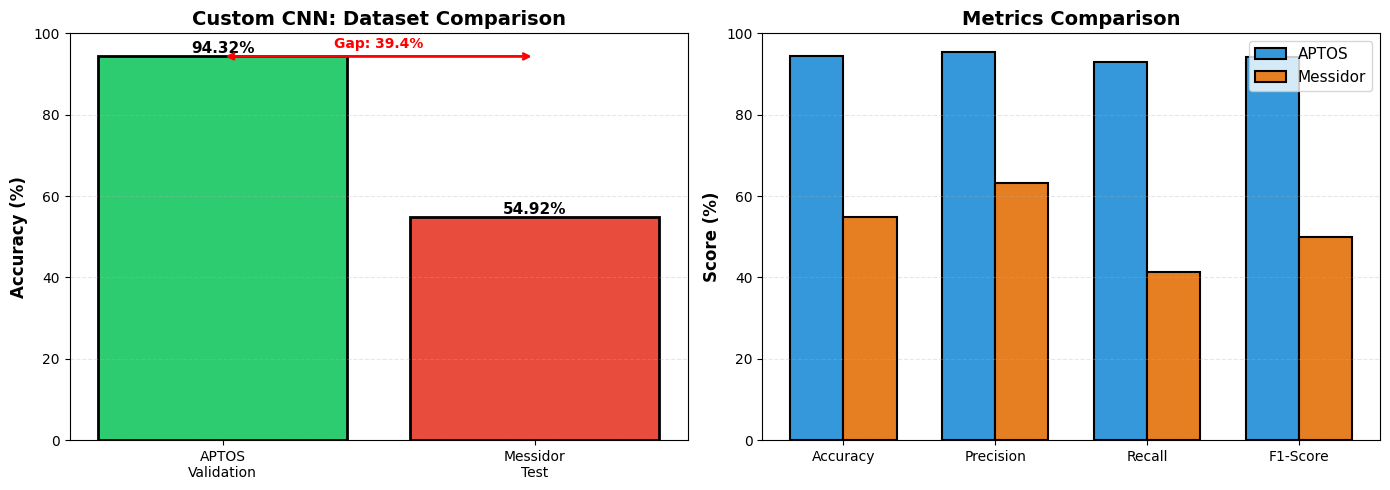

 Saved: custom_cnn_summary_table.png


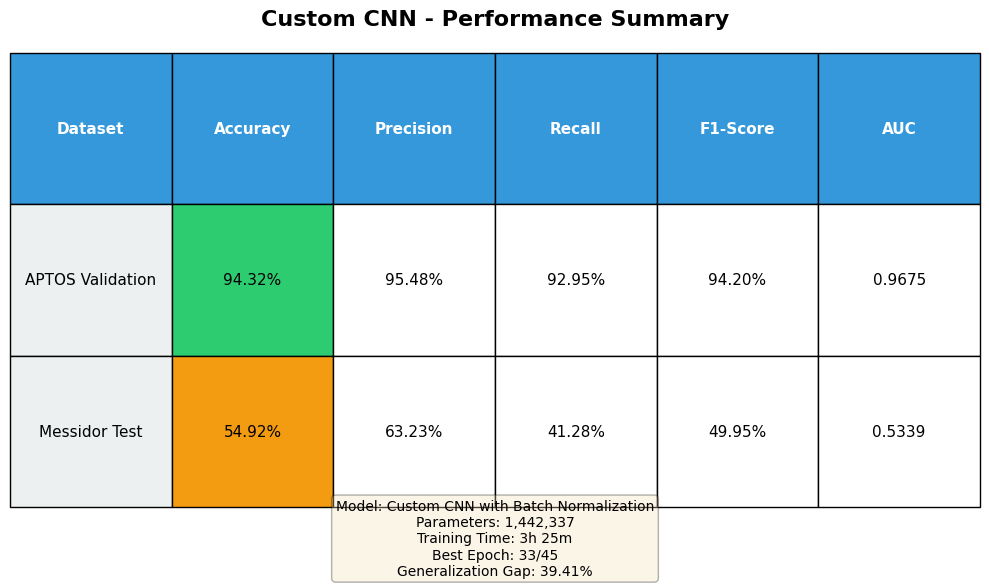

 Saved: custom_cnn_ml_comparison.png


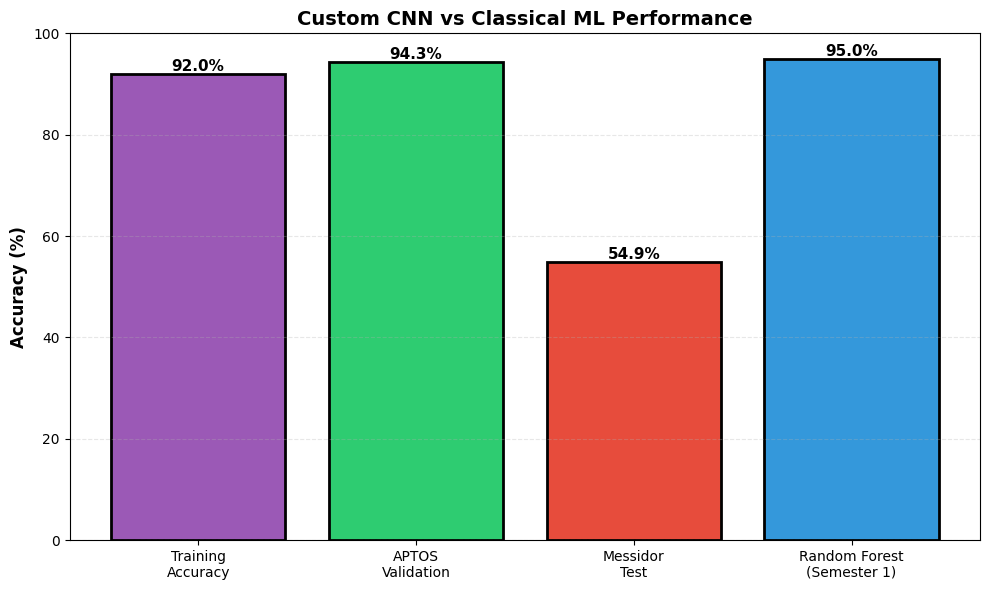


 CUSTOM CNN - ALL RESULTS SAVED!

 Files created:
  1. custom_cnn_results.csv
  2. custom_cnn_best.h5 (best model - Epoch 33)
  3. custom_cnn_final.h5 (final model)
  4. custom_cnn_performance_comparison.png
  5. custom_cnn_summary_table.png
  6. custom_cnn_ml_comparison.png

 Key Results:
  • APTOS Validation: 94.32%
  • Messidor Test: 54.92%
  • Generalization Gap: 39.41%
  • Parameters: 1,442,337


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from datetime import timedelta

print("\n" + "="*80)
print("SAVING RESULTS & CREATING VISUALIZATIONS")
print("="*80)

# Saves results to CSV
print("\nSaving results...")

results_data = {
    'Model': ['Custom CNN'],
    'Parameters': [model.count_params()],
    'Training_Time': ['3:24:54'],
    'Final_Epoch': [33],
    'APTOS_Accuracy': [val_acc],
    'APTOS_Precision': [val_precision],
    'APTOS_Recall': [val_recall],
    'APTOS_F1': [val_f1],
    'APTOS_AUC': [val_auc],
    'Messidor_Accuracy': [messidor_acc],
    'Messidor_Precision': [messidor_precision],
    'Messidor_Recall': [messidor_recall],
    'Messidor_F1': [messidor_f1],
    'Messidor_AUC': [messidor_auc],
    'Generalization_Gap': [generalization_gap]
}

results_df = pd.DataFrame(results_data)
csv_path = os.path.join(RESULTS_PATH, 'custom_cnn_results.csv')
results_df.to_csv(csv_path, index=False)
print(f" Saved: custom_cnn_results.csv")

# Saves model
model_path = os.path.join(RESULTS_PATH, 'custom_cnn_final.h5')
model.save(model_path)
print(f" Saved: custom_cnn_final.h5")

# Creates visualizations
print("\nCreating visualizations...")

# Figure 1: Accuracy Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# APTOS vs Messidor Accuracy
datasets = ['APTOS\nValidation', 'Messidor\nTest']
accuracies = [val_acc * 100, messidor_acc * 100]
colors = ['#2ecc71', '#e74c3c']

bars = axes[0].bar(datasets, accuracies, color=colors, edgecolor='black', linewidth=2)
axes[0].set_ylim([0, 100])
axes[0].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
axes[0].set_title('Custom CNN: Dataset Comparison', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Adds value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%',
                ha='center', va='bottom', fontweight='bold', fontsize=11)

# Adds generalization gap annotation
axes[0].annotate('', xy=(0, val_acc*100), xytext=(1, val_acc*100),
                arrowprops=dict(arrowstyle='<->', color='red', lw=2))
axes[0].text(0.5, val_acc*100 + 2, f'Gap: {generalization_gap*100:.1f}%',
            ha='center', color='red', fontweight='bold', fontsize=10)

# Metrics Comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
aptos_metrics = [val_acc*100, val_precision*100, val_recall*100, val_f1*100]
messidor_metrics = [messidor_acc*100, messidor_precision*100, messidor_recall*100, messidor_f1*100]

x = np.arange(len(metrics))
width = 0.35

bars1 = axes[1].bar(x - width/2, aptos_metrics, width, label='APTOS',
                   color='#3498db', edgecolor='black', linewidth=1.5)
bars2 = axes[1].bar(x + width/2, messidor_metrics, width, label='Messidor',
                   color='#e67e22', edgecolor='black', linewidth=1.5)

axes[1].set_ylabel('Score (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Metrics Comparison', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics, fontsize=10)
axes[1].legend(fontsize=11)
axes[1].set_ylim([0, 100])
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plot1_path = os.path.join(RESULTS_PATH, 'custom_cnn_performance_comparison.png')
plt.savefig(plot1_path, dpi=300, bbox_inches='tight')
print(f" Saved: custom_cnn_performance_comparison.png")
plt.show()

# Figure 2: Model Performance Summary Table
fig, ax = plt.subplots(figsize=(10, 6))

summary_data = [
    ['APTOS Validation', f'{val_acc*100:.2f}%', f'{val_precision*100:.2f}%',
     f'{val_recall*100:.2f}%', f'{val_f1*100:.2f}%', f'{val_auc:.4f}'],
    ['Messidor Test', f'{messidor_acc*100:.2f}%', f'{messidor_precision*100:.2f}%',
     f'{messidor_recall*100:.2f}%', f'{messidor_f1*100:.2f}%', f'{messidor_auc:.4f}']
]

table = ax.table(cellText=summary_data,
                colLabels=['Dataset', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC'],
                cellLoc='center',
                loc='center',
                bbox=[0, 0, 1, 1])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Style header
for i in range(6):
    table[(0, i)].set_facecolor('#3498db')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Style rows
table[(1, 0)].set_facecolor('#ecf0f1')
table[(2, 0)].set_facecolor('#ecf0f1')

# Color code accuracy cells
if val_acc >= 0.9:
    table[(1, 1)].set_facecolor('#2ecc71')
else:
    table[(1, 1)].set_facecolor('#f39c12')

if messidor_acc >= 0.7:
    table[(2, 1)].set_facecolor('#2ecc71')
elif messidor_acc >= 0.5:
    table[(2, 1)].set_facecolor('#f39c12')
else:
    table[(2, 1)].set_facecolor('#e74c3c')

ax.axis('off')
ax.set_title('Custom CNN - Performance Summary', fontsize=16, fontweight='bold', pad=20)

info_text = f'Model: Custom CNN with Batch Normalization\n'
info_text += f'Parameters: {model.count_params():,}\n'
info_text += f'Training Time: 3h 25m\n'
info_text += f'Best Epoch: 33/45\n'
info_text += f'Generalization Gap: {generalization_gap*100:.2f}%'

ax.text(0.5, -0.15, info_text, transform=ax.transAxes,
        fontsize=10, ha='center',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plot2_path = os.path.join(RESULTS_PATH, 'custom_cnn_summary_table.png')
plt.savefig(plot2_path, dpi=300, bbox_inches='tight')
print(f" Saved: custom_cnn_summary_table.png")
plt.show()

# Figure 3: Comparison with Classical ML
fig, ax = plt.subplots(figsize=(10, 6))

categories = ['Training\nAccuracy', 'APTOS\nValidation', 'Messidor\nTest', 'Random Forest\n(Semester 1)']
values = [92.0, val_acc*100, messidor_acc*100, 95.0]
colors_list = ['#9b59b6', '#2ecc71', '#e74c3c', '#3498db']

bars = ax.bar(categories, values, color=colors_list, edgecolor='black', linewidth=2)
ax.set_ylim([0, 100])
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Custom CNN vs Classical ML Performance', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plot3_path = os.path.join(RESULTS_PATH, 'custom_cnn_ml_comparison.png')
plt.savefig(plot3_path, dpi=300, bbox_inches='tight')
print(f" Saved: custom_cnn_ml_comparison.png")
plt.show()

# Print final summary
print("\n" + "="*80)
print(" CUSTOM CNN - ALL RESULTS SAVED!")
print("="*80)

print("\n Files created:")
print(f"  1. custom_cnn_results.csv")
print(f"  2. custom_cnn_best.h5 (best model - Epoch 33)")
print(f"  3. custom_cnn_final.h5 (final model)")
print(f"  4. custom_cnn_performance_comparison.png")
print(f"  5. custom_cnn_summary_table.png")
print(f"  6. custom_cnn_ml_comparison.png")

print(f"\n Key Results:")
print(f"  • APTOS Validation: {val_acc*100:.2f}%")
print(f"  • Messidor Test: {messidor_acc*100:.2f}%")
print(f"  • Generalization Gap: {generalization_gap*100:.2f}%")
print(f"  • Parameters: {model.count_params():,}")
